 Semana 5 -- Mercados y microestructura


Semana 8 - Monte Carlo, Kelly Criterion y probabilidad de ruina 

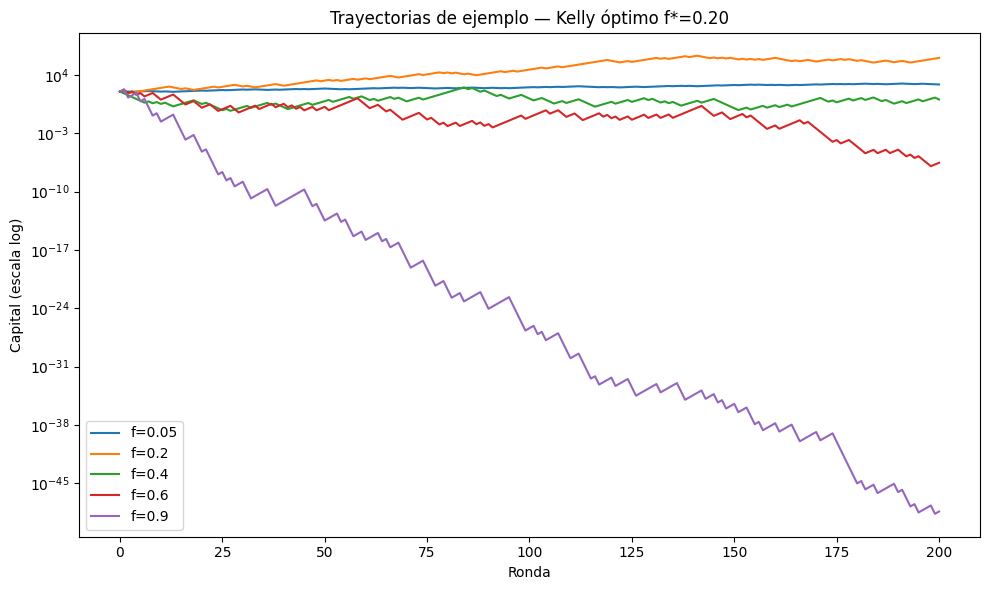

Kelly óptimo teórico: f* = 0.200

Capital MEDIANO después de 200 rondas, por cada fracción apostada:
-------------------------------------------------------
f=0.05:  Mediana capital final = $      576.24   P(ruina, capital<$1) = 0.0%
f=0.20:  Mediana capital final = $    5,609.81   P(ruina, capital<$1) = 0.2%
f=0.40:  Mediana capital final = $       61.30   P(ruina, capital<$1) = 25.4%
f=0.60:  Mediana capital final = $        0.00   P(ruina, capital<$1) = 88.7%
f=0.90:  Mediana capital final = $        0.00   P(ruina, capital<$1) = 100.0%


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

p = 0.6       # probabilidad de ganar
b = 1         # ganas 1x lo apostado si ganas
n_rondas = 200
n_simulaciones = 1000
capital_inicial = 100

fracciones = [0.05, 0.20, 0.40, 0.60, 0.90]  # incluye el Kelly óptimo (0.20) y otros valores

fig, ax = plt.subplots(figsize=(10, 6))

resultados_finales = {}

for f in fracciones:
    capitales_finales = []
    
    # Guardamos una trayectoria de ejemplo para graficar
    trayectoria_ejemplo = [capital_inicial]
    capital = capital_inicial
    
    for ronda in range(n_rondas):
        gana = np.random.random() < p
        if gana:
            capital = capital * (1 + f * b)
        else:
            capital = capital * (1 - f)
        trayectoria_ejemplo.append(capital)
    
    ax.plot(trayectoria_ejemplo, label=f"f={f}")
    
    # Ahora corremos muchas simulaciones para ver el capital final típico
    for _ in range(n_simulaciones):
        capital_sim = capital_inicial
        for ronda in range(n_rondas):
            gana = np.random.random() < p
            if gana:
                capital_sim = capital_sim * (1 + f * b)
            else:
                capital_sim = capital_sim * (1 - f)
        capitales_finales.append(capital_sim)
    
    resultados_finales[f] = capitales_finales

ax.set_yscale('log')  # escala log porque el crecimiento es exponencial
ax.set_title(f"Trayectorias de ejemplo — Kelly óptimo f*={p - (1-p)/b:.2f}")
ax.set_xlabel("Ronda")
ax.set_ylabel("Capital (escala log)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Kelly óptimo teórico: f* = {p - (1-p)/b:.3f}\n")
print("Capital MEDIANO después de 200 rondas, por cada fracción apostada:")
print("-" * 55)
for f in fracciones:
    mediana = np.median(resultados_finales[f])
    prob_ruina = np.mean(np.array(resultados_finales[f]) < 1)  # capital < $1
    print(f"f={f:.2f}:  Mediana capital final = ${mediana:>12,.2f}   "
          f"P(ruina, capital<$1) = {prob_ruina*100:.1f}%")
    


In [8]:
for f in [0.05, 0.20]:
    capitales = np.array(resultados_finales[f])
    print(f"f={f}:")
    print(f"  Mediana:        ${np.median(capitales):,.2f}")
    print(f"  Percentil 5%:   ${np.percentile(capitales, 5):,.2f}  (peor 5% de casos)")
    print(f"  Percentil 95%:  ${np.percentile(capitales, 95):,.2f}  (mejor 5% de casos)")
    print()

f=0.05:
  Mediana:        $576.24
  Percentil 5%:   $173.39  (peor 5% de casos)
  Percentil 95%:  $1,732.71  (mejor 5% de casos)

f=0.2:
  Mediana:        $5,609.81
  Percentil 5%:   $43.24  (peor 5% de casos)
  Percentil 95%:  $727,852.86  (mejor 5% de casos)



## Backtesting 

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from backtesting import Backtest, Strategy

# Descarga de datos — backtesting.py necesita columnas Open, High, Low, Close, Volume
data = yf.download("MSFT", start="2015-01-01", end="2024-12-31")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)  # aplanar columnas si vienen anidadas

data = data[["Open", "High", "Low", "Close", "Volume"]].dropna()

class CruceMediasMoviles(Strategy):
    ma_corta_periodo = 50
    ma_larga_periodo = 200
    
    def init(self):
        close = self.data.Close
        self.ma_corta = self.I(lambda x: pd.Series(x).rolling(self.ma_corta_periodo).mean(), close)
        self.ma_larga = self.I(lambda x: pd.Series(x).rolling(self.ma_larga_periodo).mean(), close)
    
    def next(self):
        if self.ma_corta[-1] > self.ma_larga[-1] and not self.position:
            self.buy()
        elif self.ma_corta[-1] < self.ma_larga[-1] and self.position:
            self.position.close()

bt = Backtest(data, CruceMediasMoviles, cash=10000, commission=0.001)  # 0.1% por operación
resultado = bt.run()
print(resultado)

c:\Users\sismo\OneDrive - CINVESTAV\Cinvestav\Proyectos personales\Becoming a Quant Trader\RoadMap2BecomeAQuant\venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/2315 [00:00<?, ?bar/s]

Start                     2015-01-02 00:00:00
End                       2024-12-30 00:00:00
Duration                   3650 days 00:00:00
Exposure Time [%]                    79.76143
Equity Final [$]                  86279.85751
Equity Peak [$]                  100951.00392
Commissions [$]                     282.78693
Return [%]                          762.79858
Buy & Hold Return [%]               920.57407
Return (Ann.) [%]                    24.10149
Volatility (Ann.) [%]                29.38631
CAGR [%]                             16.04227
Sharpe Ratio                          0.82016
Sortino Ratio                         1.53182
Calmar Ratio                          0.86071
Alpha [%]                            79.72941
Beta                                    0.742
Max. Drawdown [%]                   -28.00175
Avg. Drawdown [%]                    -2.94586
Max. Drawdown Duration      549 days 00:00:00
Avg. Drawdown Duration       24 days 00:00:00
# Trades                          

C:\Users\sismo\AppData\Local\Temp\ipykernel_54244\803405636.py:29: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  resultado = bt.run()


In [2]:
print(resultado._trades)

   Size  EntryBar  ExitBar  EntryPrice   ExitPrice    SL    TP           PnL  \
0   243       201      375   41.077917   44.126859  None  None    720.188157   
1   213       398     1035   50.262691  100.136106  None  None  10591.002570   
2   208      1051     1814  102.116640  283.108412  None  None  37566.161874   
3   219      2067     2495  267.940553  416.627564  None  None  32412.535137   

   Commission  ReturnPct  EntryTime   ExitTime  Duration   Tag  Entry_λ(C)  \
0   20.704760   0.072149 2015-10-20 2016-06-29  253 days  None   38.472790   
1   32.034944   0.989263 2016-08-02 2019-02-13  925 days  None   46.335958   
2   80.126811   1.768630 2019-03-08 2022-03-17 1105 days  None   98.793590   
3  149.920418   0.552370 2023-03-21 2024-12-02  622 days  None  245.049597   

    Exit_λ(C)  
0   45.325507  
1   97.614227  
2  289.421316  
3  415.713507  


In [3]:
ma_corta_check = data["Close"].rolling(50).mean()
ma_larga_check = data["Close"].rolling(200).mean()
señal_check = (ma_corta_check > ma_larga_check).astype(int)
print(f"Número de cambios de señal: {(señal_check.diff() != 0).sum()}")

Número de cambios de señal: 10


In [5]:
# Extraer las series de MA calculadas DENTRO del backtest
ma_corta_bt = resultado._strategy.ma_corta
ma_larga_bt = resultado._strategy.ma_larga

print("Primeros 5 valores MA corta (backtest):", ma_corta_bt[:5])
print("Primeros 5 valores MA corta (manual):  ", ma_corta_check.values[:5])

print(f"\nLongitud MA corta backtest: {len(ma_corta_bt)}")
print(f"Longitud datos originales:  {len(data)}")

Primeros 5 valores MA corta (backtest): [nan nan nan nan nan]
Primeros 5 valores MA corta (manual):   [nan nan nan nan nan]

Longitud MA corta backtest: 2515
Longitud datos originales:  2515


In [6]:
# Comparar valores donde ambas series ya tienen datos (después del NaN inicial)
import numpy as np

diferencias = np.abs(ma_corta_bt[250:260] - ma_corta_check.values[250:260])
print("MA corta backtest [250:260]:", ma_corta_bt[250:260])
print("MA corta manual   [250:260]:", ma_corta_check.values[250:260])
print("Diferencias:", diferencias)

MA corta backtest [250:260]: [47.032351   47.17234795 47.31036026 47.43835732 47.46510178 47.43517052
 47.41772636 47.39473732 47.39085365 47.37956375]
MA corta manual   [250:260]: [47.032351   47.17234795 47.31036026 47.43835732 47.46510178 47.43517052
 47.41772636 47.39473732 47.39085365 47.37956375]
Diferencias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
cruce_alcista = (ma_corta_check > ma_larga_check) & (ma_corta_check.shift(1) <= ma_larga_check.shift(1))
print(f"Número de cruces alcistas (compra) esperados: {cruce_alcista.sum()}")

cruce_bajista = (ma_corta_check < ma_larga_check) & (ma_corta_check.shift(1) >= ma_larga_check.shift(1))
print(f"Número de cruces bajistas (venta) esperados: {cruce_bajista.sum()}")

print("\nFechas de cruces alcistas:")
print(data.index[cruce_alcista])

Número de cruces alcistas (compra) esperados: 4
Número de cruces bajistas (venta) esperados: 4

Fechas de cruces alcistas:
DatetimeIndex(['2016-08-01', '2019-03-07', '2023-03-20', '2024-12-11'], dtype='datetime64[ns]', name='Date', freq=None)


In [9]:
años = (data.index[-1] - data.index[0]).days / 365.25
retorno_anualizado_equiv = (1 + 7.6279)**(1/años) - 1
print(f"Retorno anualizado equivalente: {retorno_anualizado_equiv*100:.2f}%")

print(resultado)

Retorno anualizado equivalente: 24.07%
Start                     2015-01-02 00:00:00
End                       2024-12-30 00:00:00
Duration                   3650 days 00:00:00
Exposure Time [%]                    79.76143
Equity Final [$]                  86279.85751
Equity Peak [$]                  100951.00392
Commissions [$]                     282.78693
Return [%]                          762.79858
Buy & Hold Return [%]               920.57407
Return (Ann.) [%]                    24.10149
Volatility (Ann.) [%]                29.38631
CAGR [%]                             16.04227
Sharpe Ratio                          0.82016
Sortino Ratio                         1.53182
Calmar Ratio                          0.86071
Alpha [%]                            79.72941
Beta                                    0.742
Max. Drawdown [%]                   -28.00175
Avg. Drawdown [%]                    -2.94586
Max. Drawdown Duration      549 days 00:00:00
Avg. Drawdown Duration       24 days 00:0

In [10]:
from scipy.stats import binomtest

resultado_test = binomtest(4, n=4, p=0.5, alternative='greater')
print(f"p-value con 4/4 trades ganadores: {resultado_test.pvalue:.4f}")

p-value con 4/4 trades ganadores: 0.0625


In [1]:
from scipy.stats import binomtest

resultado = binomtest(178, n=444, p=0.5, alternative='greater')
print(f"p-value (¿winrate > 50%?): {resultado.pvalue:.4f}")

p-value (¿winrate > 50%?): 1.0000


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

# EUR/USD con velas de 1 hora (yfinance limita el historial intraday, usamos lo disponible)
data = yf.download("EURUSD=X", start="2024-01-01", end="2024-12-31", interval="1h")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data = data.dropna()
data.index = data.index.tz_convert("UTC") if data.index.tz else data.index.tz_localize("UTC")
data["hora"] = data.index.hour
data["fecha"] = data.index.date

trades = []

for fecha, grupo_dia in data.groupby("fecha"):
    asia = grupo_dia[(grupo_dia["hora"] >= 0) & (grupo_dia["hora"] < 8)]
    if len(asia) == 0:
        continue
    
    rango_alto = asia["High"].max()
    rango_bajo = asia["Low"].min()
    
    resto_dia = grupo_dia[grupo_dia["hora"] >= 8]
    
    ruptura_detectada = False
    direccion = None
    esperando_retest = False
    
    for idx, vela in resto_dia.iterrows():
        if not ruptura_detectada:
            if vela["Close"] > rango_alto:
                ruptura_detectada = True
                direccion = "alcista"
            elif vela["Close"] < rango_bajo:
                ruptura_detectada = True
                direccion = "bajista"
            continue
        
        if direccion == "alcista":
            if vela["Low"] <= rango_alto:
                esperando_retest = True
            if esperando_retest and vela["Close"] > rango_alto:
                precio_entrada = vela["Close"]
                # Salida: cierre del día (simplificación, ajustamos después)
                precio_salida = resto_dia.iloc[-1]["Close"]
                retorno = (precio_salida - precio_entrada) / precio_entrada
                trades.append({"fecha": fecha, "direccion": "alcista", "retorno": retorno})
                break
        
        elif direccion == "bajista":
            if vela["High"] >= rango_bajo:
                esperando_retest = True
            if esperando_retest and vela["Close"] < rango_bajo:
                precio_entrada = vela["Close"]
                precio_salida = resto_dia.iloc[-1]["Close"]
                retorno = (precio_entrada - precio_salida) / precio_entrada  # short: ganas si baja
                trades.append({"fecha": fecha, "direccion": "bajista", "retorno": retorno})
                break

df_trades = pd.DataFrame(trades)
print(f"Número de trades: {len(df_trades)}")
print(f"Winrate: {(df_trades['retorno'] > 0).mean()*100:.2f}%")
print(f"Retorno promedio por trade: {df_trades['retorno'].mean()*100:.4f}%")
print(df_trades.head(10))

$EURUSD=X: possibly delisted; no price data found  (1h 2024-01-01 -> 2024-12-31) (Yahoo error = "1h data not available for startTime=1704067200 and endTime=1735603200. The requested range must be within the last 730 days.")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['EURUSD=X']: possibly delisted; no price data found  (1h 2024-01-01 -> 2024-12-31) (Yahoo error = "1h data not available for startTime=1704067200 and endTime=1735603200. The requested range must be within the last 730 days.")


Número de trades: 0


KeyError: 'retorno'

In [3]:
print(f"Número de elementos en trades: {len(trades)}")
print(f"Número de días distintos procesados: {data['fecha'].nunique()}")

Número de elementos en trades: 0
Número de días distintos procesados: 0


In [4]:
print(f"Filas totales descargadas: {len(data)}")
print(data.index.min(), "a", data.index.max())

Filas totales descargadas: 0
NaT a NaT


In [6]:
import yfinance as yf
from datetime import datetime, timedelta

hoy = datetime.now()
hace_6_meses = hoy - timedelta(days=180)

test2 = yf.download("EURUSD=X", start=hace_6_meses.strftime("%Y-%m-%d"), 
                     end=hoy.strftime("%Y-%m-%d"), interval="1h")
print(f"Shape: {test2.shape}")
print(test2.head())

[*********************100%***********************]  1 of 1 completed

Shape: (3011, 5)
Price                         Close      High       Low      Open   Volume
Ticker                     EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Datetime                                                                  
2026-01-12 00:00:00+00:00  1.166725  1.166725  1.162656  1.162791        0
2026-01-12 01:00:00+00:00  1.166045  1.167406  1.165909  1.166861        0
2026-01-12 02:00:00+00:00  1.165909  1.166725  1.165909  1.165909        0
2026-01-12 03:00:00+00:00  1.165909  1.166181  1.165909  1.165909        0
2026-01-12 04:00:00+00:00  1.165909  1.166181  1.165637  1.165909        0


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

hoy = datetime.now()
hace_6_meses = hoy - timedelta(days=180)

data = yf.download("EURUSD=X", start=hace_6_meses.strftime("%Y-%m-%d"), 
                    end=hoy.strftime("%Y-%m-%d"), interval="1h")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data = data.dropna()

# El índice ya viene con tz UTC (+00:00) según tu output, verificamos:
print(f"Timezone del índice: {data.index.tz}")

data.index = data.index.tz_convert("UTC")
data["hora"] = data.index.hour
data["fecha"] = data.index.date

print(f"Timezone despues de convertir : {data.index.tz}")
print(data.index[:3])

trades = []

for fecha, grupo_dia in data.groupby("fecha"):
    asia = grupo_dia[(grupo_dia["hora"] >= 0) & (grupo_dia["hora"] < 8)]
    if len(asia) == 0:
        continue
    
    rango_alto = asia["High"].max()
    rango_bajo = asia["Low"].min()
    
    resto_dia = grupo_dia[grupo_dia["hora"] >= 8]
    
    ruptura_detectada = False
    direccion = None
    esperando_retest = False
    
    for idx, vela in resto_dia.iterrows():
        if not ruptura_detectada:
            if vela["Close"] > rango_alto:
                ruptura_detectada = True
                direccion = "alcista"
            elif vela["Close"] < rango_bajo:
                ruptura_detectada = True
                direccion = "bajista"
            continue
        
        if direccion == "alcista":
            if vela["Low"] <= rango_alto:
                esperando_retest = True
            if esperando_retest and vela["Close"] > rango_alto:
                precio_entrada = vela["Close"]
                precio_salida = resto_dia.iloc[-1]["Close"]
                retorno = (precio_salida - precio_entrada) / precio_entrada
                trades.append({"fecha": fecha, "direccion": "alcista", "retorno": retorno})
                break
        
        elif direccion == "bajista":
            if vela["High"] >= rango_bajo:
                esperando_retest = True
            if esperando_retest and vela["Close"] < rango_bajo:
                precio_entrada = vela["Close"]
                precio_salida = resto_dia.iloc[-1]["Close"]
                retorno = (precio_entrada - precio_salida) / precio_entrada
                trades.append({"fecha": fecha, "direccion": "bajista", "retorno": retorno})
                break

df_trades = pd.DataFrame(trades)
print(f"\nNúmero de trades: {len(df_trades)}")
if len(df_trades) > 0:
    print(f"Winrate: {(df_trades['retorno'] > 0).mean()*100:.2f}%")
    print(f"Retorno promedio por trade: {df_trades['retorno'].mean()*100:.4f}%")

[*********************100%***********************]  1 of 1 completed

Timezone del índice: Europe/London
Timezone despues de convertir : UTC
DatetimeIndex(['2026-01-14 00:00:00+00:00', '2026-01-14 01:00:00+00:00',
               '2026-01-14 02:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Datetime', freq=None)

Número de trades: 85
Winrate: 47.06%
Retorno promedio por trade: -0.0139%


In [2]:
from scipy.stats import ttest_1samp

resultado_ttest = ttest_1samp(df_trades["retorno"], popmean=0)
print(f"t-statistic: {resultado_ttest.statistic:.4f}")
print(f"p-value: {resultado_ttest.pvalue:.4f}")

if resultado_ttest.pvalue < 0.05:
    print("→ El retorno promedio es estadísticamente distinto de cero")
else:
    print("→ NO hay evidencia de que el retorno promedio sea distinto de cero (podría ser ruido)")

t-statistic: -0.5330
p-value: 0.5955
→ NO hay evidencia de que el retorno promedio sea distinto de cero (podría ser ruido)
